In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

df = pd.read_csv('kickstarter_clean.csv')

X = df.drop(columns=['State'])
y = df['State']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

print(classification_report(y_test, preds))
print(f1_score(y_test, rf.predict(X_test), average='weighted'))

              precision    recall  f1-score   support

           0       0.70      0.77      0.73     38925
           1       0.61      0.53      0.56     26740

    accuracy                           0.67     65665
   macro avg       0.65      0.65      0.65     65665
weighted avg       0.66      0.67      0.66     65665

0.6633628899078219


In [ ]:
# what depth is best for the random forest:

for depth in [5, 10, 15, 20, 25, 30, 40, None]:
    rf = RandomForestClassifier(max_depth=depth, random_state=42)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    f1 = f1_score(y_test, preds, average='weighted')
    train = rf.score(X_train, y_train)
    print(f"depth={depth}: Train={train:.3f}  F1={f1:.3f}")

depth=5: Train=0.620  F1=0.518
depth=10: Train=0.660  F1=0.618
depth=15: Train=0.685  F1=0.643
depth=20: Train=0.724  F1=0.659
depth=25: Train=0.785  F1=0.669
depth=30: Train=0.859  F1=0.670
depth=40: Train=0.952  F1=0.670
depth=None: Train=0.989  F1=0.663


depth of 25 is ideal for the random forest. Increasing the depth does not improve the performance significantly, but it increases the training time and the risk of overfitting. Therefore, I will keep the depth of 25 for the final model.

In [12]:
# n_estimators tuning: How many Trees are ideal:

for n in [50, 100, 200, 300]:
    rf = RandomForestClassifier(max_depth=25, n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    f1 = f1_score(y_test, preds, average='weighted')
    print(f"n_estimators={n}: F1={f1:.3f}")

n_estimators=50: F1=0.668
n_estimators=100: F1=0.669
n_estimators=200: F1=0.669
n_estimators=300: F1=0.669


with the default of 100 trees the random forest is stable. Increasing the number of trees does not improve the performance significantly, but it increases the training time. Therefore, I will keep the default of 100 trees for the final model.

In [13]:
# min_sample_split tuning: How many samples are needed to split a node:

for mss in [2, 5, 10, 20, 50]:
    rf = RandomForestClassifier(max_depth=25, n_estimators=100, 
                                min_samples_split=mss, random_state=42)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    f1 = f1_score(y_test, preds, average='weighted')
    train = rf.score(X_train, y_train)
    print(f"min_samples_split={mss}: Train={train:.3f}  F1={f1:.3f}")

min_samples_split=2: Train=0.785  F1=0.669
min_samples_split=5: Train=0.754  F1=0.670
min_samples_split=10: Train=0.735  F1=0.671
min_samples_split=20: Train=0.717  F1=0.671
min_samples_split=50: Train=0.703  F1=0.670


In [14]:
# max_features tuning: How many features are considered for splitting a node:

for mf in ['sqrt', 'log2', 0.3, 0.5]:
    rf = RandomForestClassifier(max_depth=25, n_estimators=100,
                                min_samples_split=20, max_features=mf,
                                random_state=42)
    rf.fit(X_train, y_train)
    preds = rf.predict(X_test)
    f1 = f1_score(y_test, preds, average='weighted')
    train = rf.score(X_train, y_train)
    print(f"max_features={mf}: Train={train:.3f}  F1={f1:.3f}")

max_features=sqrt: Train=0.717  F1=0.671
max_features=log2: Train=0.703  F1=0.655
max_features=0.3: Train=0.763  F1=0.683
max_features=0.5: Train=0.779  F1=0.683


In [15]:
# final random forest model: max_depth=25, n_estimators=100, min_samples_split=20, max_features=0.3
rf = RandomForestClassifier(max_depth=25, n_estimators=100,
                            min_samples_split=20, max_features=0.3,
                            random_state=42)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

print(classification_report(y_test, preds))
print(f1_score(y_test, rf.predict(X_test), average='weighted'))

              precision    recall  f1-score   support

           0       0.71      0.81      0.76     38925
           1       0.65      0.52      0.58     26740

    accuracy                           0.69     65665
   macro avg       0.68      0.66      0.67     65665
weighted avg       0.69      0.69      0.68     65665

0.683363592455576


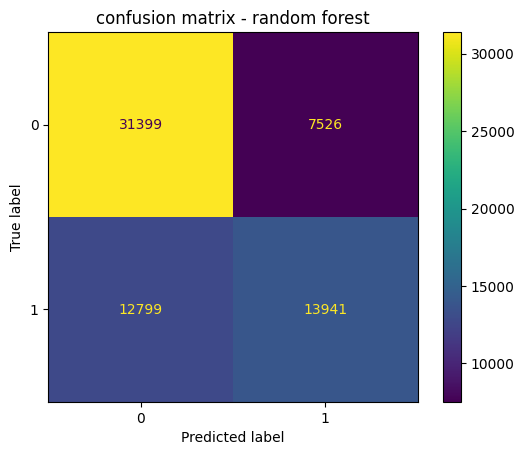

In [18]:
# confusion matrix:

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from matplotlib import pyplot as plt

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,)
disp.plot()
plt.title('confusion matrix - random forest')
plt.show()

In [19]:
# Fehler als DataFrame anschauen
X_test_copy = X_test.copy()
X_test_copy['true'] = y_test.values
X_test_copy['predicted'] = preds

# Nur falsche Vorhersagen
errors = X_test_copy[X_test_copy['true'] != X_test_copy['predicted']]
print(f"Anzahl Fehler: {len(errors)}")
print(f"Fehlerrate: {len(errors)/len(X_test):.2%}")

Anzahl Fehler: 20325
Fehlerrate: 30.95%


In [ ]:
# error analysis goal: 

errors = X_test_copy[X_test_copy['true'] != X_test_copy['predicted']]
correct = X_test_copy[X_test_copy['true'] == X_test_copy['predicted']]

print(f"Errors:  {len(errors)}")
print(f"Correct: {len(correct)}")

print("\nErrors - Goal:")
print(errors['Goal'].describe().round(0))

print("\nCorrect - Goal:")
print(correct['Goal'].describe().round(0))

Errors:  20325
Correct: 45340

Errors - Goal:
count     20325.0
mean      10612.0
std       18547.0
min           1.0
25%        1700.0
50%        5000.0
75%       11000.0
max      300000.0
Name: Goal, dtype: float64

Correct - Goal:
count     45340.0
mean      17533.0
std       33837.0
min           1.0
25%        2000.0
50%        5500.0
75%       16500.0
max      300000.0
Name: Goal, dtype: float64


In [ ]:
# Error in Duration:

print("Errors - Duration:")
print(errors['Duration'].describe().round(0))

print("\nCorrect - Duration:")
print(correct['Duration'].describe().round(0))

Errors - Duration:
count    20325.0
mean        32.0
std         12.0
min          1.0
25%         29.0
50%         29.0
75%         34.0
max         91.0
Name: Duration, dtype: float64

Correct - Duration:
count    45340.0
mean        33.0
std         13.0
min          1.0
25%         29.0
50%         29.0
75%         36.0
max         91.0
Name: Duration, dtype: float64


Goal                          0.256725
Duration                      0.157009
launch_year                   0.077641
launch_month                  0.073420
launch_dayofweek              0.054539
Subcategory_Tabletop Games    0.034747
Category_Music                0.019242
Category_Theater              0.016089
Category_Comics               0.014647
Subcategory_Hip-Hop           0.013191
Country_United States         0.010962
Subcategory_Shorts            0.010527
Subcategory_Apps              0.009686
Country_United Kingdom        0.008636
Category_Technology           0.007623
dtype: float64


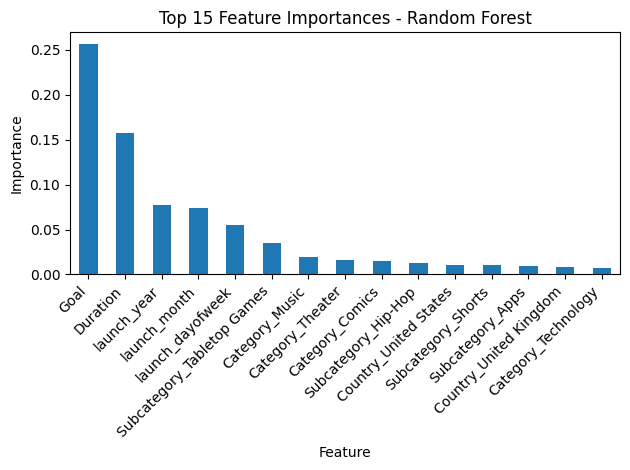

In [28]:
# Feature importance:

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Top 15
print(feature_importance.head(15))

# Plot
feature_importance.head(15).plot(kind='bar')
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Summary:

model configuration after tuning:
- max_depth=25
- n_estimators=100
- min_samples_split=20
- max_features=0.3

Perfomence:

Baseline (Decision Tree):           F1-score: 0.604
Random Forest (Default):            F1-score: 0.669
Random Forest (Tuned):              F1-score: 0.683  

Tuning improved model +0.079 over baseline

Classification Report:

Class 0 (Failed):                   Precision=0.71  Recall=0.81  F1=0.76
Class 1 (Successful):               Precision=0.65  Recall=0.52  F1=0.58
Weighted avg:                       F1=0.683

Tuning Process:

max_depth:                          Sweet spot at 25 — deeper trees showed diminishing returns and increasing overfitting
n_estimators:                       No improvement beyond 100 trees — default sufficient
min_samples_split:                  20 gave best balance between F1 and overfitting
max_features:                       0.3 (30% of features per tree) outperformed default sqrt

Error Analysis:

Overall errors: 
Total errors:                       20325/ 65665
Error rate:                         30.95%                  


Confusion matrix:

True Failed  → predicted Failed:     31.399  
True Failed  → predicted Successful:  7.526  
True Success → predicted Failed:     12.799  
True Success → predicted Successful: 13.941 

The model misses 48% of successful projects — predicting them as Failed. This is the biggest weakness.
Where errors occur:

Goal: Errors concentrated at lower goals (median 5k vs 5.5k for correct predictions) — low-goal projects are harder to classify as they can be either Successful or Failed
Duration: Almost no difference between errors and correct predictions — Duration does not influence where the model fails

Root cause: Class imbalance (59% Failed / 41% Successful) causes the model to lean towards predicting Failed.

Feature Importances (Top 5):
1. Goal:              26%  ← most important by far
2. Duration:          16%
3. launch_year:        8%
4. launch_month:       8%
5. launch_dayofweek:   6%

Goal and Duration alone account for ~42% of all decisions, confirming our EDA findings. Date features (launch timing) contribute a surprising ~22%, suggesting seasonality plays a role in campaign success.


Key takeaway:

The model performs well on Failed projects (Recall=0.81) but struggles with Successful ones (Recall=0.52). The primary driver is class imbalance. 
